In [564]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("khushikyad001/electric-vehicle-analytics-dataset")

# print("Path to dataset files:", path)

## Import

In [565]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer, PolynomialFeatures
from sklearn.compose import ColumnTransformer

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader, Dataset
import torch.optim as optim

import pytorch_lightning as pl
from pytorch_lightning import LightningModule
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger

from torchmetrics.regression import R2Score, MeanSquaredError, MeanAbsoluteError
from torchmetrics.functional import r2_score, mean_squared_error, mean_absolute_error

import pytorch_optimizer as optim1
import optuna
pd.set_option('display.max_columns', 1000)
pl.seed_everything(42)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

Seed set to 42


## Eda

In [566]:
df = pd.read_csv('electric_vehicle_analytics.csv', index_col='Vehicle_ID')
df

,Make,Model,Year,Region,Vehicle_Type,Battery_Capacity_kWh,Battery_Health_%,Range_km,Charging_Power_kW,Charging_Time_hr,Charge_Cycles,Energy_Consumption_kWh_per_100km,Mileage_km,Avg_Speed_kmh,Max_Speed_kmh,Acceleration_0_100_kmh_sec,Temperature_C,Usage_Type,CO2_Saved_tons,Maintenance_Cost_USD,Insurance_Cost_USD,Electricity_Cost_USD_per_kWh,Monthly_Charging_Cost_USD,Resale_Value_USD
Vehicle_ID,,,,,,,,,,,,,,,,,,,,,,,,
1,Nissan,Leaf,2021,Asia,SUV,101.7,75.5,565,153.6,0.82,1438,12.76,117727,53.4,233,8.10,-9.0,Personal,14.13,969,843,0.30,375.55,26483
2,Nissan,Leaf,2020,Australia,Sedan,30.1,99.8,157,157.2,0.27,1056,15.79,161730,58.0,221,9.83,1.6,Personal,19.41,1157,1186,0.25,532.02,11287
3,Hyundai,Kona Electric,2021,North America,SUV,118.5,84.0,677,173.6,0.84,1497,24.34,244931,69.4,138,3.60,1.5,Fleet,29.39,291,1890,0.26,1291.68,34023
4,Audi,Q4 e-tron,2022,Europe,Hatchback,33.1,97.3,149,169.3,0.25,1613,14.70,57995,42.9,192,8.97,12.5,Fleet,6.96,401,2481,0.33,234.44,14398
5,Tesla,Model 3,2022,Australia,Truck,81.3,85.6,481,212.8,0.43,1078,22.77,17185,97.6,189,7.03,-3.0,Commercial,2.06,214,2336,0.10,32.61,23033
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2996,Mercedes,EQS,2021,North America,SUV,57.2,84.0,239,102.2,0.69,1242,21.39,130400,43.2,154,7.98,33.7,Personal,15.65,1645,2357,0.33,767.05,16749
2997,Ford,Mustang Mach-E,2022,Europe,Hatchback,98.4,83.1,498,160.6,0.74,1793,18.62,15175,41.8,243,7.22,13.7,Fleet,1.82,289,868,0.32,75.35,30080
2998,Kia,Niro EV,2024,Europe,Truck,35.1,82.1,189,18.1,2.56,1184,20.34,219055,33.6,175,4.26,5.8,Fleet,26.29,1013,695,0.32,1188.15,16286


In [567]:
df.isnull().sum()
df.drop_duplicates()

,Make,Model,Year,Region,Vehicle_Type,Battery_Capacity_kWh,Battery_Health_%,Range_km,Charging_Power_kW,Charging_Time_hr,Charge_Cycles,Energy_Consumption_kWh_per_100km,Mileage_km,Avg_Speed_kmh,Max_Speed_kmh,Acceleration_0_100_kmh_sec,Temperature_C,Usage_Type,CO2_Saved_tons,Maintenance_Cost_USD,Insurance_Cost_USD,Electricity_Cost_USD_per_kWh,Monthly_Charging_Cost_USD,Resale_Value_USD
Vehicle_ID,,,,,,,,,,,,,,,,,,,,,,,,
1,Nissan,Leaf,2021,Asia,SUV,101.7,75.5,565,153.6,0.82,1438,12.76,117727,53.4,233,8.10,-9.0,Personal,14.13,969,843,0.30,375.55,26483
2,Nissan,Leaf,2020,Australia,Sedan,30.1,99.8,157,157.2,0.27,1056,15.79,161730,58.0,221,9.83,1.6,Personal,19.41,1157,1186,0.25,532.02,11287
3,Hyundai,Kona Electric,2021,North America,SUV,118.5,84.0,677,173.6,0.84,1497,24.34,244931,69.4,138,3.60,1.5,Fleet,29.39,291,1890,0.26,1291.68,34023
4,Audi,Q4 e-tron,2022,Europe,Hatchback,33.1,97.3,149,169.3,0.25,1613,14.70,57995,42.9,192,8.97,12.5,Fleet,6.96,401,2481,0.33,234.44,14398
5,Tesla,Model 3,2022,Australia,Truck,81.3,85.6,481,212.8,0.43,1078,22.77,17185,97.6,189,7.03,-3.0,Commercial,2.06,214,2336,0.10,32.61,23033
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2996,Mercedes,EQS,2021,North America,SUV,57.2,84.0,239,102.2,0.69,1242,21.39,130400,43.2,154,7.98,33.7,Personal,15.65,1645,2357,0.33,767.05,16749
2997,Ford,Mustang Mach-E,2022,Europe,Hatchback,98.4,83.1,498,160.6,0.74,1793,18.62,15175,41.8,243,7.22,13.7,Fleet,1.82,289,868,0.32,75.35,30080
2998,Kia,Niro EV,2024,Europe,Truck,35.1,82.1,189,18.1,2.56,1184,20.34,219055,33.6,175,4.26,5.8,Fleet,26.29,1013,695,0.32,1188.15,16286


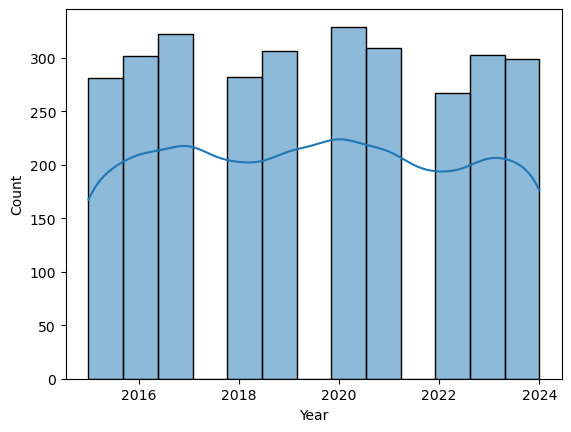

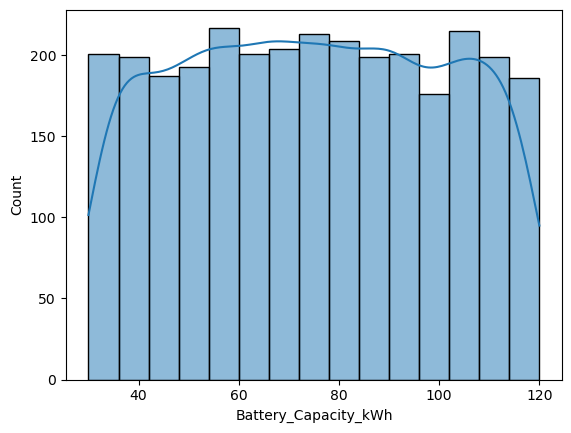

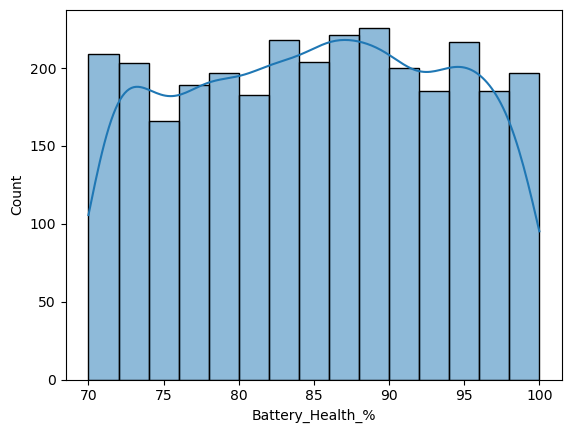

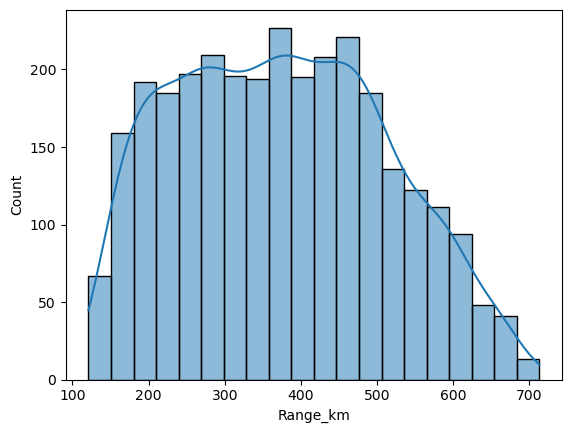

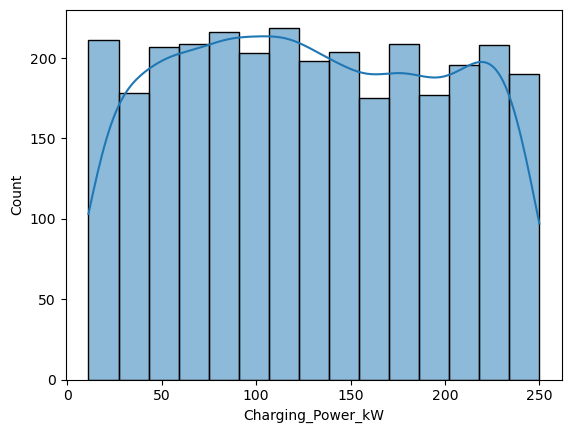

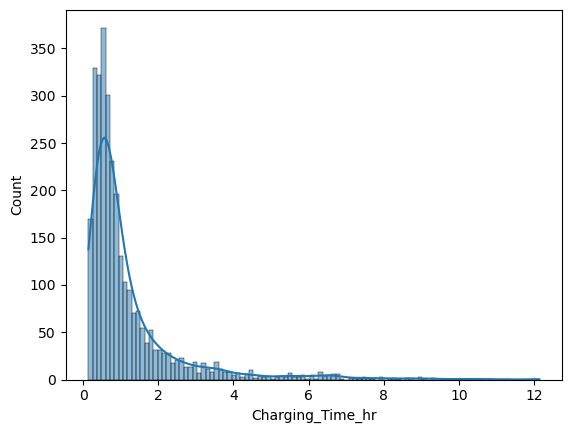

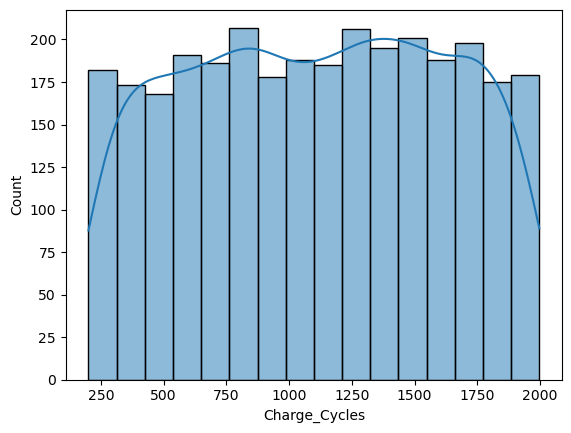

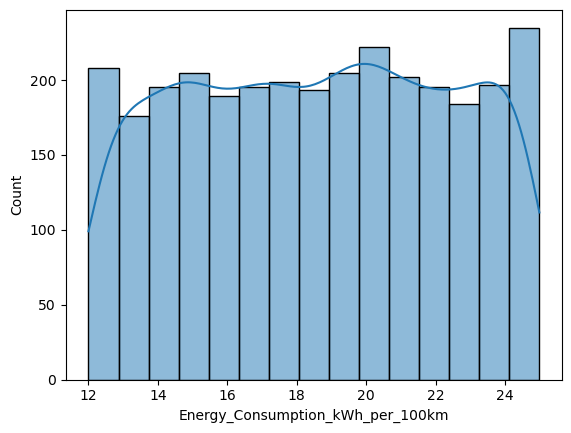

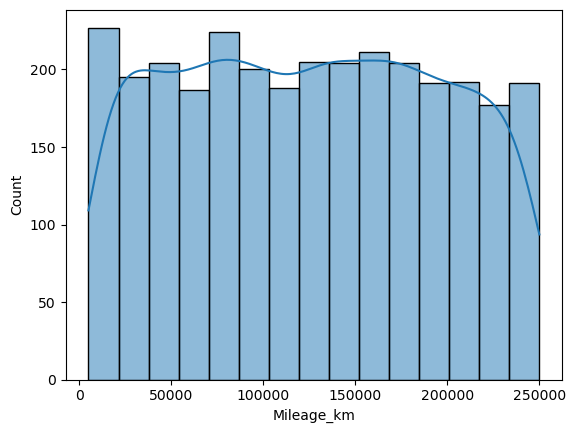

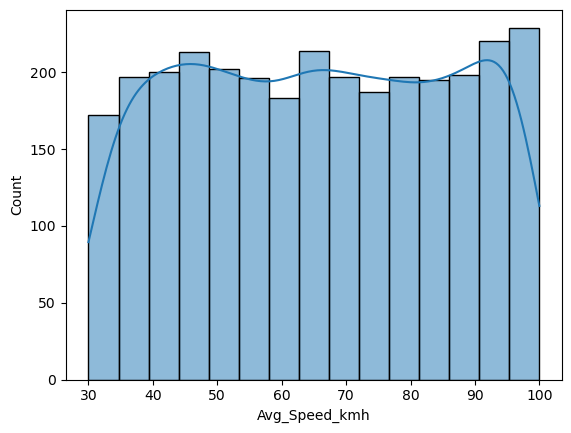

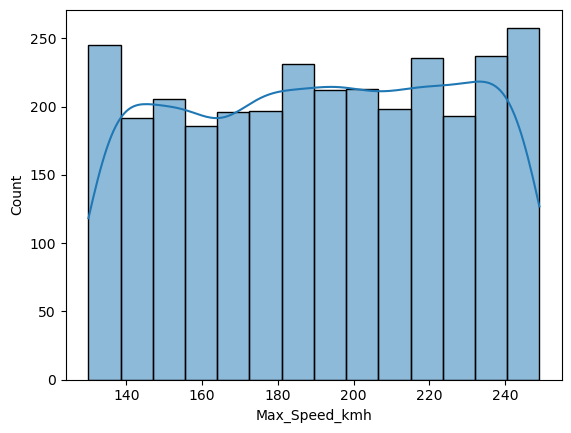

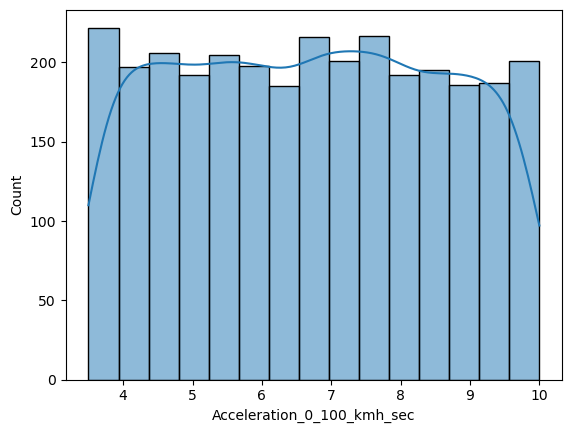

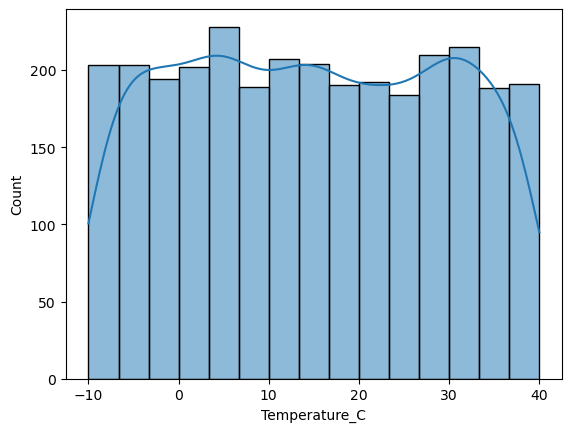

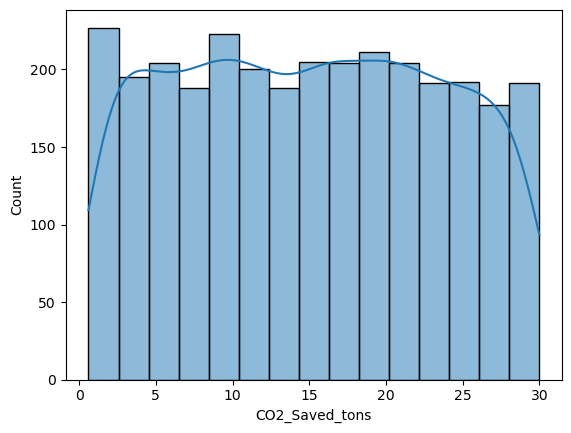

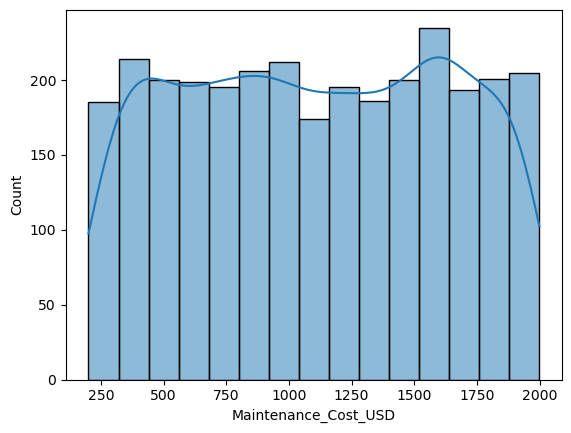

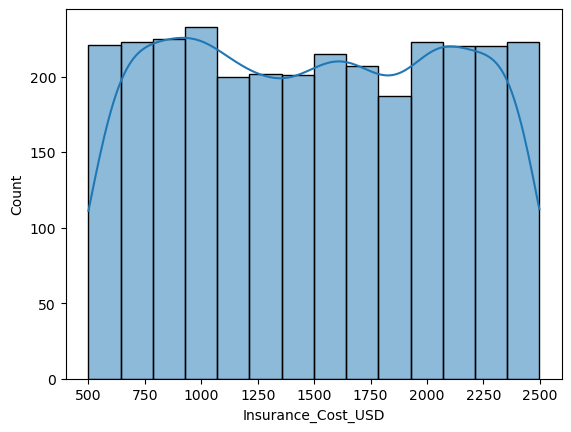

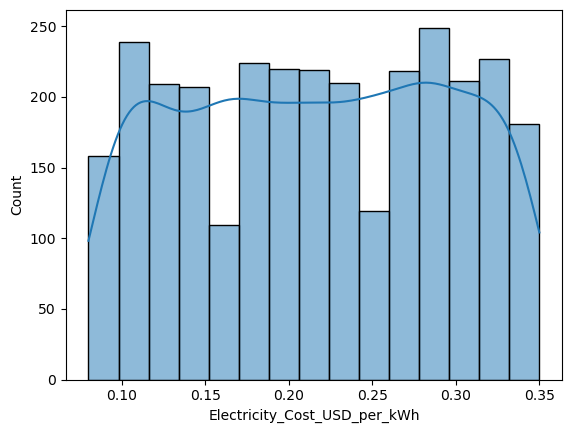

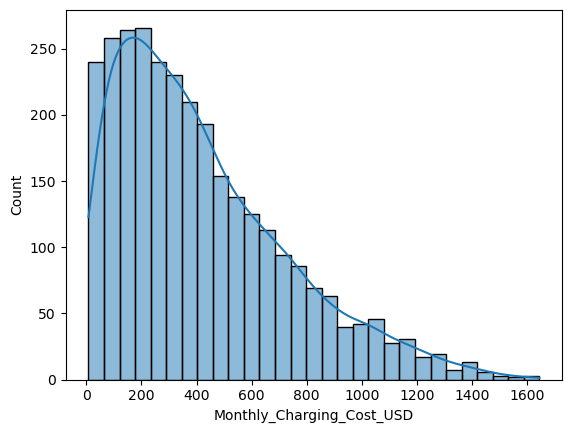

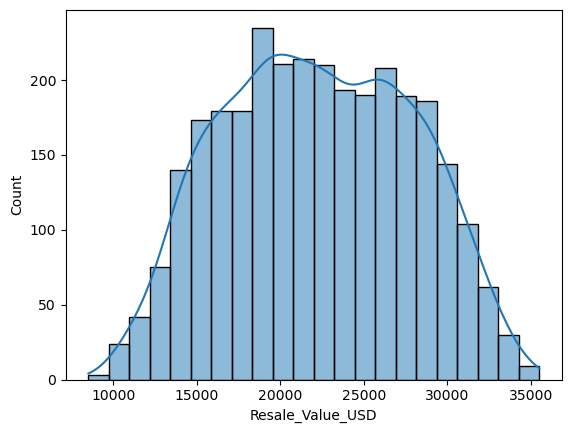

In [568]:
for i in df.select_dtypes(exclude='object').columns:
    sns.histplot(df[i], kde=True)
    plt.show()

In [569]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3000 entries, 1 to 3000
Data columns (total 24 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              3000 non-null   object 
 1   Model                             3000 non-null   object 
 2   Year                              3000 non-null   int64  
 3   Region                            3000 non-null   object 
 4   Vehicle_Type                      3000 non-null   object 
 5   Battery_Capacity_kWh              3000 non-null   float64
 6   Battery_Health_%                  3000 non-null   float64
 7   Range_km                          3000 non-null   int64  
 8   Charging_Power_kW                 3000 non-null   float64
 9   Charging_Time_hr                  3000 non-null   float64
 10  Charge_Cycles                     3000 non-null   int64  
 11  Energy_Consumption_kWh_per_100km  3000 non-null   float64
 12  Mileage_km 

## Prepare for embedding

In [570]:
for i in df.select_dtypes(include='object').columns:
    print(f'{i}: {df[i].nunique()}')

Make: 10
Model: 23
Region: 4
Vehicle_Type: 4
Usage_Type: 3


In [571]:
df

,Make,Model,Year,Region,Vehicle_Type,Battery_Capacity_kWh,Battery_Health_%,Range_km,Charging_Power_kW,Charging_Time_hr,Charge_Cycles,Energy_Consumption_kWh_per_100km,Mileage_km,Avg_Speed_kmh,Max_Speed_kmh,Acceleration_0_100_kmh_sec,Temperature_C,Usage_Type,CO2_Saved_tons,Maintenance_Cost_USD,Insurance_Cost_USD,Electricity_Cost_USD_per_kWh,Monthly_Charging_Cost_USD,Resale_Value_USD
Vehicle_ID,,,,,,,,,,,,,,,,,,,,,,,,
1,Nissan,Leaf,2021,Asia,SUV,101.7,75.5,565,153.6,0.82,1438,12.76,117727,53.4,233,8.10,-9.0,Personal,14.13,969,843,0.30,375.55,26483
2,Nissan,Leaf,2020,Australia,Sedan,30.1,99.8,157,157.2,0.27,1056,15.79,161730,58.0,221,9.83,1.6,Personal,19.41,1157,1186,0.25,532.02,11287
3,Hyundai,Kona Electric,2021,North America,SUV,118.5,84.0,677,173.6,0.84,1497,24.34,244931,69.4,138,3.60,1.5,Fleet,29.39,291,1890,0.26,1291.68,34023
4,Audi,Q4 e-tron,2022,Europe,Hatchback,33.1,97.3,149,169.3,0.25,1613,14.70,57995,42.9,192,8.97,12.5,Fleet,6.96,401,2481,0.33,234.44,14398
5,Tesla,Model 3,2022,Australia,Truck,81.3,85.6,481,212.8,0.43,1078,22.77,17185,97.6,189,7.03,-3.0,Commercial,2.06,214,2336,0.10,32.61,23033
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2996,Mercedes,EQS,2021,North America,SUV,57.2,84.0,239,102.2,0.69,1242,21.39,130400,43.2,154,7.98,33.7,Personal,15.65,1645,2357,0.33,767.05,16749
2997,Ford,Mustang Mach-E,2022,Europe,Hatchback,98.4,83.1,498,160.6,0.74,1793,18.62,15175,41.8,243,7.22,13.7,Fleet,1.82,289,868,0.32,75.35,30080
2998,Kia,Niro EV,2024,Europe,Truck,35.1,82.1,189,18.1,2.56,1184,20.34,219055,33.6,175,4.26,5.8,Fleet,26.29,1013,695,0.32,1188.15,16286


### Train Test split

In [572]:
X_num = df.select_dtypes(exclude='object')
X_cat = df.select_dtypes(include='object')
X_num = X_num.drop(columns='Resale_Value_USD', axis=1)
y = df.Resale_Value_USD

X_num_train, X_num_test, X_cat_train, X_cat_test, y_train, y_test = train_test_split(X_num, X_cat, y, random_state=42, test_size=0.2)

In [573]:
embedding_sizes = []
mapping = {}
for i in X_cat.select_dtypes(include='object').columns:
    col_map = {cat:i for i, cat in enumerate(X_cat[i].unique())}
    mapping[i] = col_map
    X_cat_train[i] = X_cat_train[i].map(col_map)
    X_cat_test[i] = X_cat_test[i].map(col_map)
    embedding_sizes.append((len(col_map), min(50, (len(col_map) + 1) // 2)))

In [574]:
num = X_num.columns.to_list()
cat = X_cat.columns.to_list()
num, cat

(['Year',
  'Battery_Capacity_kWh',
  'Battery_Health_%',
  'Range_km',
  'Charging_Power_kW',
  'Charging_Time_hr',
  'Charge_Cycles',
  'Energy_Consumption_kWh_per_100km',
  'Mileage_km',
  'Avg_Speed_kmh',
  'Max_Speed_kmh',
  'Acceleration_0_100_kmh_sec',
  'Temperature_C',
  'CO2_Saved_tons',
  'Maintenance_Cost_USD',
  'Insurance_Cost_USD',
  'Electricity_Cost_USD_per_kWh',
  'Monthly_Charging_Cost_USD'],
 ['Make', 'Model', 'Region', 'Vehicle_Type', 'Usage_Type'])

In [575]:
embedding_sizes, mapping
X_cat_train

,Make,Model,Region,Vehicle_Type,Usage_Type
Vehicle_ID,,,,,
643,5,7,1,1,2
701,5,7,1,2,1
227,5,14,2,0,0
1698,6,20,2,0,1
1011,9,16,1,3,1
...,...,...,...,...,...
1639,6,20,2,2,0
1096,5,14,3,1,1
1131,2,2,2,1,2


### Feature Transform

In [576]:
num_pipe = Pipeline([
    ('power', PowerTransformer()),
    ('scaler', StandardScaler())
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, num)
])
X_num_train = preprocessor.fit_transform(X_num_train)
X_num_test = preprocessor.transform(X_num_test)
preprocessor1 = ColumnTransformer([
    ('target', StandardScaler(), ['Resale_Value_USD'])
])
y_train = preprocessor1.fit_transform(y_train.to_frame())
y_test = preprocessor1.transform(y_test.to_frame())
y_train

array([[-1.46705168],
       [ 1.31402006],
       [-0.24683282],
       ...,
       [ 0.60439556],
       [-0.27679435],
       [ 0.13089643]])

## Neural-Network

In [577]:
def conv_block(in_feature, out_feature, padding=1, stride=1,
             activation="relu", pool =True, maxpool=True, kernel_size=3,
             kernel_size_pool=2, pool_stride=2)-> list[nn.Sequential]:
    layers = [nn.Conv2d(in_feature, out_feature, kernel_size=kernel_size, padding=padding, stride=stride)]
    if activation == "relu":
        layers.append(nn.ReLU())
    elif activation == "leakyrelu":
        layers.append(nn.LeakyReLU())
    elif activation == "sigmoid":
        layers.append(nn.Sigmoid())
    elif activation == "tanh":
        layers.append(nn.Tanh())
    if pool:
        if maxpool:
            layers.append(nn.MaxPool2d(kernel_size=kernel_size_pool, stride=pool_stride))
        else:
            layers.append(nn.AvgPool2d(kernel_size=kernel_size_pool, stride=pool_stride))
    else:
        layers.append(nn.Identity())
    return nn.Sequential(*layers)


def linear_block(in_features, out_features, activation=None, dropout=0.0, batch_norm=None):
    layers = [nn.Linear(in_features, out_features)]
    if batch_norm:
        layers.append(nn.BatchNorm1d(out_features))
    if activation == 'relu':
        layers.append(nn.ReLU())
    elif activation == 'sigmoid':
        layers.append(nn.Sigmoid())
    elif activation == 'tanh':
        layers.append(nn.Tanh())
    elif activation == 'leakyrelu':
        layers.append(nn.LeakyReLU())
    elif activation == 'mish': layers.append(nn.Mish())
    elif activation == 'softmax':
        layers.append(nn.Softmax(dim=1))
    elif activation == 'elu':
        layers.append(nn.ELU())
    elif activation == 'selu':
        layers.append(nn.SELU())
    elif activation == 'lsoftmax':
        layers.append(nn.LogSoftmax(dim=1))
    if dropout > 0.0:
        layers.append(nn.Dropout(dropout))
    return nn.Sequential(*layers)

In [578]:
class CharbonnierLoss(nn.Module):
    def __init__(self, epsilon=1e-3):
        super().__init__()
        self.epsilon_sq = epsilon**2

    def forward(self, y_pred, y_true):
        error = y_pred - y_true
        return torch.mean(torch.sqrt(error**2 + self.epsilon_sq))
    
class LogCoshLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, y_pred, y_true):
        error = y_pred - y_true
        return torch.mean(torch.log(torch.cosh(error)))


In [579]:
from typing import Any
from pytorch_optimizer import SophiaH

class EmbbedDataset(Dataset):
    def __init__(self, X_cat, X_num, y) -> None:
        super().__init__()
        self.categorical = torch.tensor(X_cat, dtype=torch.long)
        self.numeric = torch.tensor(X_num, dtype=torch.float32)
        self.labels = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.categorical[idx], self.numeric[idx], self.labels[idx]
    
class ANN(LightningModule):
    def __init__(self, embedding_sizes, num_numerical) -> None:
        super().__init__()
        self.embedding = nn.ModuleList([nn.Embedding(vocab_size, dim) for vocab_size, dim in embedding_sizes])
        num_embedding_dim = sum(dim for _, dim in embedding_sizes)
        self.fc = nn.Sequential(
            linear_block(num_embedding_dim+ num_numerical, 8, activation='mish', batch_norm=True, dropout=0),
            linear_block(8, 8, activation='mish', batch_norm=True, dropout=0),
            linear_block(8, 4, activation='mish', batch_norm=True, dropout=0),
            # linear_block(4, 4, activation='mish', batch_norm=True),
            linear_block(4, 1, activation=None, batch_norm=None)
        )
    def forward(self, X_cat, X_num):
        embedd_feature = [emb(X_cat[:, i]) for i, emb in enumerate(self.embedding)]
        total_embedd = torch.cat(embedd_feature, dim=1)
        combine_feature = torch.cat([total_embedd, X_num], dim=1)
        return self.fc(combine_feature)
    
class PL(LightningModule):
    def __init__(self, model, learning_rate) -> None:
        super().__init__()
        self.model = model
        self.learning_rate = learning_rate
        self.criterion = LogCoshLoss()
        self.r2 = R2Score()
    
    def forward(self, X_cat, X_num) -> Any:
        return self.model(X_cat, X_num)

    def training_step(self, batch, batch_idx):
        X_cat, X_num, labels = batch
        # labels = labels.unsqueeze(1)
        outputs = self(X_cat, X_num)
        loss = self.criterion(outputs, labels)
        r2 = self.r2(outputs, labels)
        self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True, logger=True)
        self.log('train_r2', r2, on_step=True, on_epoch=True, prog_bar=True, logger=True)
        return loss

    def validation_step(self, batch, batch_idx):
        X_cat, X_num, labels = batch
        # labels = labels.unsqueeze(1)
        outputs = self(X_cat, X_num)
        loss = self.criterion(outputs, labels)
        r2 = self.r2(outputs, labels)
        self.log('val_loss', loss, on_epoch=True, prog_bar=True, logger=True)
        self.log('val_r2', r2, on_epoch=True, prog_bar=True, logger=True)

    def test_step(self, batch, batch_idx):
        X_cat, X_num, labels = batch
        # labels = labels.unsqueeze(1)
        outputs = self(X_cat, X_num)
        loss = self.criterion(outputs, labels)
        r2 = self.r2(outputs, labels)
        self.log('test_loss', loss, on_epoch=True, prog_bar=True, logger=True)
        self.log('test_r2', r2, on_epoch=True, prog_bar=True, logger=True)

    def backward(self, loss, *args, **kwargs):
        loss.backward(create_graph=True)

    def configure_optimizers(self):
        optimizer = optim1.Lion(self.parameters(), lr=self.learning_rate)
        return optimizer

    def predict_step(self, batch, batch_idx, dataloader_idx=None):
        X_cat, X_num, _ = batch
        return self(X_cat, X_num)

## Config

In [ ]:
if torch.cuda.is_available():
    accelerator_type = 'gpu'
    devices_to_use = 1
else:
    accelerator_type = 'cpu'
    devices_to_use = 'auto'

checkpoint_callback = ModelCheckpoint(
    monitor='val_loss',
    dirpath='checkpoints/',
    filename='ElectricV-{epoch:02d}-{val_loss:.2f}',
    save_top_k=1,
    mode='min'
)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    mode='min',
)
lr_monitor_callback = LearningRateMonitor(logging_interval='epoch')

trainer1 = pl.Trainer(
    max_epochs=300,
    callbacks=[checkpoint_callback, early_stopping, lr_monitor_callback],
    logger=TensorBoardLogger("tb_logs", name="simple_model_experiment"),
    accelerator=accelerator_type,
    devices=devices_to_use,
    log_every_n_steps=10,
    deterministic=True,
    
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


## Embedding Dataset

In [581]:
bs = 64
trainset = EmbbedDataset(X_cat_train.values, X_num_train, y_train)
trainloader = DataLoader(trainset, batch_size=bs, shuffle=True)

testset = EmbbedDataset(X_cat_test.values, X_num_test, y_test)
testloader = DataLoader(testset, batch_size=bs, shuffle=False)

In [582]:
feature, feature1, target = next(iter(testloader))
feature.shape, feature1.shape, target.shape

(torch.Size([64, 5]), torch.Size([64, 18]), torch.Size([64, 1]))

## Training

In [583]:
model = PL(ANN(embedding_sizes, feature1.shape[1]), learning_rate=1e-3)

In [584]:
trainer1.fit(model, trainloader, testloader)


  | Name      | Type        | Params | Mode 
--------------------------------------------------
0 | model     | ANN         | 837    | train
1 | criterion | LogCoshLoss | 0      | train
2 | r2        | R2Score     | 0      | train
--------------------------------------------------
837       Trainable params
0         Non-trainable params
837       Total params
0.003     Total estimated model params size (MB)
24        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

## Eval

In [585]:
trainer1.validate(model, testloader, ckpt_path='best')

Restoring states from the checkpoint path at C:\Users\dsapu\Project\Python\repo\dlp\Electric Vehicle\checkpoints\ElectricV-epoch=16-val_loss=0.05.ckpt
Loaded model weights from the checkpoint at C:\Users\dsapu\Project\Python\repo\dlp\Electric Vehicle\checkpoints\ElectricV-epoch=16-val_loss=0.05.ckpt


Validation: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         val_loss          │    0.04887682944536209    │
│          val_r2           │    0.8952029347419739     │
└───────────────────────────┴───────────────────────────┘

[{'val_loss': 0.04887682944536209, 'val_r2': 0.8952029347419739}]